<a href="https://colab.research.google.com/github/bioinformaticswoman/Breast-Cancer-Drug-Discovery-Model/blob/main/BC_model_updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [81]:
!pip install chembl_webresource_client
!apt-get install -y python3-rdkit

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
python3-rdkit is already the newest version (202109.2-1build1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [82]:
!pip install chembl_webresource_client
!pip install rdkit

import pandas as pd
import numpy as np
from chembl_webresource_client.new_client import new_client

from rdkit import Chem
from rdkit.Chem import Descriptors

In [83]:
from chembl_webresource_client.new_client import new_client
import pandas as pd

target = new_client.target
target_query = target.search('ESR1')
targets = pd.DataFrame(target_query)

targets.head()

,cross_references,organism,pref_name,score,species_group_flag,target_chembl_id,target_components,target_type,tax_id
0,[],Homo sapiens,Estrogen receptor,12.0,False,CHEMBL206,"[{'accession': 'P03372', 'component_descriptio...",SINGLE PROTEIN,9606
1,[],Mus musculus,Estrogen receptor,12.0,False,CHEMBL3065,"[{'accession': 'P19785', 'component_descriptio...",SINGLE PROTEIN,10090
2,[],Rattus norvegicus,Estrogen receptor,12.0,False,CHEMBL2724,"[{'accession': 'P06211', 'component_descriptio...",SINGLE PROTEIN,10116
3,[],Bos taurus,Estrogen receptor,12.0,False,CHEMBL2930,"[{'accession': 'P49884', 'component_descriptio...",SINGLE PROTEIN,9913
4,[],Ovis aries,Estrogen receptor,12.0,False,CHEMBL2021744,"[{'accession': 'P49885', 'component_descriptio...",SINGLE PROTEIN,9940


In [84]:
selected_target = targets.target_chembl_id[0]
selected_target

'CHEMBL206'

In [85]:
activity = new_client.activity
res = activity.filter(target_chembl_id=selected_target).filter(standard_type="IC50")

df = pd.DataFrame(res)
df.head()

,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,...,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
0,None,None,72003,[],CHEMBL679321,Binding affinity towards human estrogen recept...,B,None,None,BAO_0000190,...,Homo sapiens,Estrogen receptor,9606,None,None,IC50,nM,UO_0000065,None,2.5
1,None,None,74062,[],CHEMBL679321,Binding affinity towards human estrogen recept...,B,None,None,BAO_0000190,...,Homo sapiens,Estrogen receptor,9606,None,None,IC50,nM,UO_0000065,None,7.5
2,None,None,76289,[],CHEMBL679321,Binding affinity towards human estrogen recept...,B,None,None,BAO_0000190,...,Homo sapiens,Estrogen receptor,9606,None,None,IC50,nM,UO_0000065,None,3.1
3,None,None,77402,[],CHEMBL679321,Binding affinity towards human estrogen recept...,B,None,None,BAO_0000190,...,Homo sapiens,Estrogen receptor,9606,None,None,IC50,nM,UO_0000065,None,3.9
4,None,None,78475,[],CHEMBL679321,Binding affinity towards human estrogen recept...,B,None,None,BAO_0000190,...,Homo sapiens,Estrogen receptor,9606,None,None,IC50,nM,UO_0000065,None,7.4


In [86]:
df = df[['canonical_smiles','standard_value']]
df = df.dropna()
df.head()

,canonical_smiles,standard_value
0,Oc1ccc2c(c1)S[C@H](C1CCCC1)[C@H](c1ccc(OCCN3CC...,2.5
1,Oc1ccc2c(c1)S[C@H](C1CCCCCC1)[C@H](c1ccc(OCCN3...,7.5
2,Oc1ccc([C@H]2Sc3cc(O)ccc3O[C@H]2c2ccc(OCCN3CCC...,3.1
3,Oc1ccc2c(c1)S[C@H](CC1CCCCC1)[C@H](c1ccc(OCCN3...,3.9
4,Oc1ccc2c(c1)S[C@H](Cc1ccccc1)[C@H](c1ccc(OCCN3...,7.4


In [87]:
df['standard_value'] = pd.to_numeric(df['standard_value'], errors='coerce')
df = df.dropna()

In [88]:
def convert_to_pIC50(ic50):
    return -np.log10(ic50 * 1e-9)

df['pIC50'] = df['standard_value'].apply(convert_to_pIC50)
df.head()

,canonical_smiles,standard_value,pIC50
0,Oc1ccc2c(c1)S[C@H](C1CCCC1)[C@H](c1ccc(OCCN3CC...,2.5,8.602060
1,Oc1ccc2c(c1)S[C@H](C1CCCCCC1)[C@H](c1ccc(OCCN3...,7.5,8.124939
2,Oc1ccc([C@H]2Sc3cc(O)ccc3O[C@H]2c2ccc(OCCN3CCC...,3.1,8.508638
3,Oc1ccc2c(c1)S[C@H](CC1CCCCC1)[C@H](c1ccc(OCCN3...,3.9,8.408935
4,Oc1ccc2c(c1)S[C@H](Cc1ccccc1)[C@H](c1ccc(OCCN3...,7.4,8.130768


In [89]:
def compute_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return {
        "MolWt": Descriptors.MolWt(mol),
        "LogP": Descriptors.MolLogP(mol),
        "NumHDonors": Descriptors.NumHDonors(mol),
        "NumHAcceptors": Descriptors.NumHAcceptors(mol)
    }

desc_list = df['canonical_smiles'].apply(compute_descriptors)
desc_df = pd.DataFrame(desc_list.tolist())

desc_df.head()

,MolWt,LogP,NumHDonors,NumHAcceptors
0,439.621,6.0415,1,5
1,467.675,6.8217,1,5
2,463.599,5.9296,2,6
3,467.675,6.8217,1,5
4,461.627,6.0940,1,5


In [90]:
df_final = pd.concat([df, desc_df], axis=1)
df_final.head()

,canonical_smiles,standard_value,pIC50,MolWt,LogP,NumHDonors,NumHAcceptors
0,Oc1ccc2c(c1)S[C@H](C1CCCC1)[C@H](c1ccc(OCCN3CC...,2.5,8.602060,439.621,6.0415,1.0,5.0
1,Oc1ccc2c(c1)S[C@H](C1CCCCCC1)[C@H](c1ccc(OCCN3...,7.5,8.124939,467.675,6.8217,1.0,5.0
2,Oc1ccc([C@H]2Sc3cc(O)ccc3O[C@H]2c2ccc(OCCN3CCC...,3.1,8.508638,463.599,5.9296,2.0,6.0
3,Oc1ccc2c(c1)S[C@H](CC1CCCCC1)[C@H](c1ccc(OCCN3...,3.9,8.408935,467.675,6.8217,1.0,5.0
4,Oc1ccc2c(c1)S[C@H](Cc1ccccc1)[C@H](c1ccc(OCCN3...,7.4,8.130768,461.627,6.0940,1.0,5.0


In [91]:
from rdkit import Chem
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from rdkit import DataStructs
import numpy as np

morgan_gen = GetMorganGenerator(radius=2, fpSize=1024)

def fingerprint(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(1024)

    fp = morgan_gen.GetFingerprint(mol)

    arr = np.zeros((1024,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)

    return arr

    fp = np.array(df_final['canonical_smiles'].apply(fingerprint).tolist())
print(fp.shape)

(5507, 1024)


In [92]:


from rdkit import Chem
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from rdkit import DataStructs
import numpy as np

df_final = df_final.dropna().reset_index(drop=True)

morgan_gen = GetMorganGenerator(radius=2, fpSize=1024)

def fingerprint(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(1024)

    fp = morgan_gen.GetFingerprint(mol)

    arr = np.zeros((1024,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)

    return arr

fp = np.array(df_final['canonical_smiles'].apply(fingerprint).tolist())

X_basic = df_final[['MolWt','LogP','NumHDonors','NumHAcceptors']].values

X = np.concatenate([X_basic, fp], axis=1)

y = df_final['pIC50']

print("X_basic shape:", X_basic.shape)
print("Fingerprint shape:", fp.shape)
print("Final X shape:", X.shape)
print("y shape:", y.shape)

X_basic shape: (5507, 4)
Fingerprint shape: (5507, 1024)
Final X shape: (5507, 1028)
y shape: (5507,)


In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

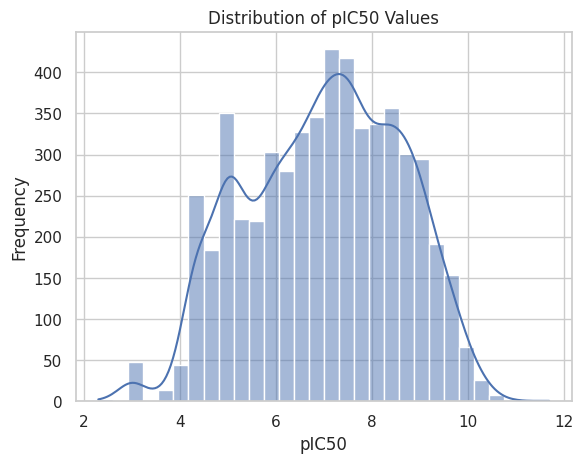

In [94]:
plt.figure()
sns.histplot(y, bins=30, kde=True)
plt.xlabel("pIC50")
plt.ylabel("Frequency")
plt.title("Distribution of pIC50 Values")
plt.savefig("pic50_distribution.png")
plt.show()

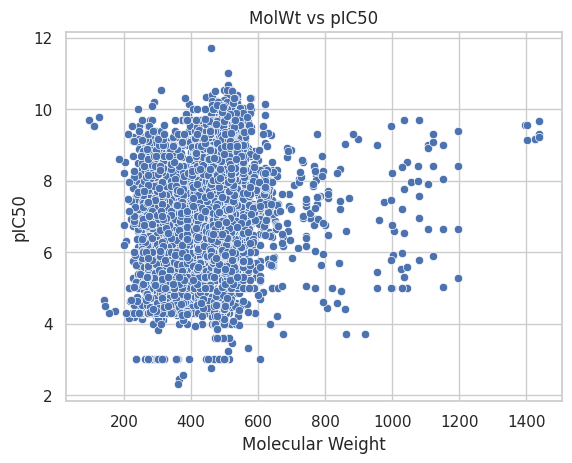

In [95]:
plt.figure()
sns.scatterplot(x=df_final['MolWt'], y=y)
plt.xlabel("Molecular Weight")
plt.ylabel("pIC50")
plt.title("MolWt vs pIC50")
plt.savefig("molwt_vs_pic50.png")
plt.show()

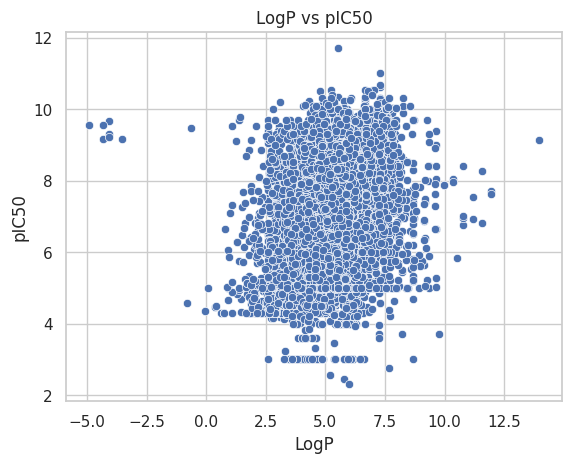

In [96]:

plt.figure()
sns.scatterplot(x=df_final['LogP'], y=y)
plt.xlabel("LogP")
plt.ylabel("pIC50")
plt.title("LogP vs pIC50")
plt.savefig("logp_vs_pic50.png")
plt.show()

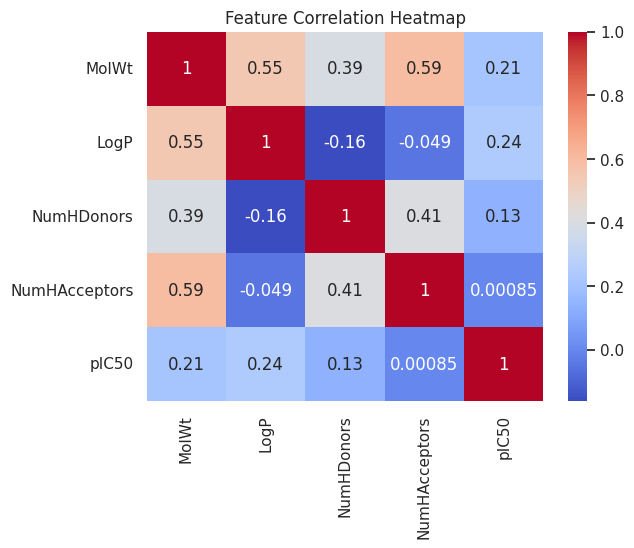

In [97]:


plt.figure()
corr = df_final[['MolWt','LogP','NumHDonors','NumHAcceptors','pIC50']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.savefig("correlation_heatmap.png")
plt.show()

In [98]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("R2:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2: 0.7374166310201618
RMSE: 0.8034770493095889


In [99]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [100]:

from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

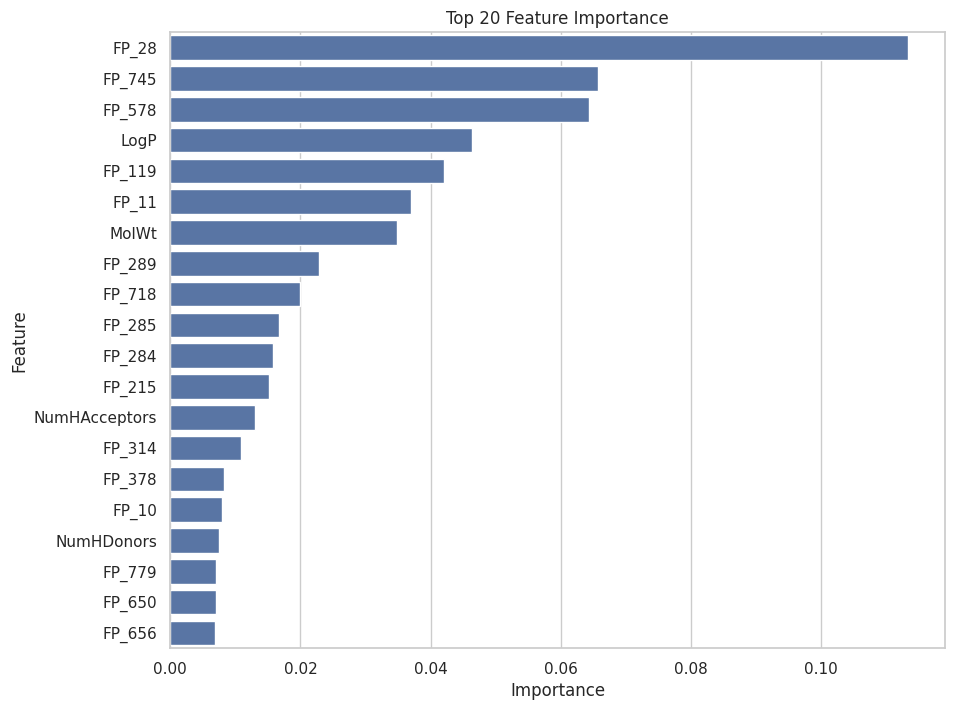

In [101]:
importances = model.feature_importances_

descriptor_names = ['MolWt', 'LogP', 'NumHDonors', 'NumHAcceptors']
fingerprint_names = [f'FP_{i}' for i in range(fp.shape[1])]
feature_names = descriptor_names + fingerprint_names

feature_importance_series = pd.Series(importances, index=feature_names)

feature_importance_series = feature_importance_series.sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=feature_importance_series.head(20).values, y=feature_importance_series.head(20).index) # Plot top 20 features
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importance")
plt.show()

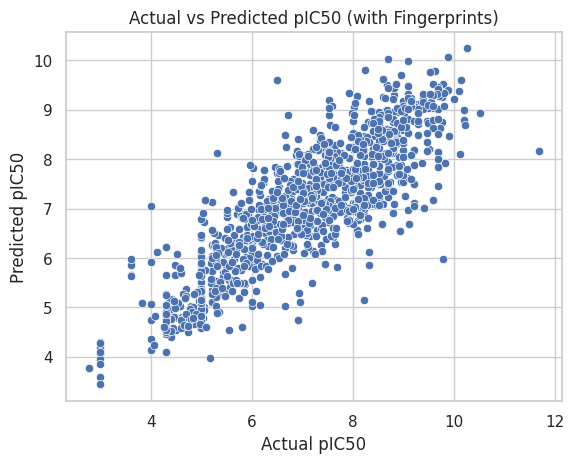

In [102]:

plt.figure()
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual pIC50")
plt.ylabel("Predicted pIC50")
plt.title("Actual vs Predicted pIC50 (with Fingerprints)")
plt.savefig("predicted_vs_actual.png")
plt.show()